# Module 02: A Box Model of Land-Atmosphere Carbon Balance

### 1. Introduction


In [16]:
import numpy as np
import matplotlib.pyplot as plt

M1i = 1066.66
M2i = 333.33

k12 = 0.0003 
k21 = 0.1

ti = 0.0
tf = 100.0
dt = 1


In [3]:
t = np.arange(ti,tf+dt,dt)

Nt = t.size

print('t has '+str(Nt)+' time steps')

t has 36501 time steps


In [4]:
M1 = np.zeros((Nt,)) #creates empty space for our model to fill 
M2 = np.zeros((Nt,))

In [5]:
for i in np.arange(Nt):
    if (i==0):

        M1[i] = M1i #setting initial land and atmospheric carbon mass values for first time step
        M2[i] = M2i
        
    else:
        dM1dt = k21*M2[i-1] - k12*M1[i-1]*M2[i-1] #calculating the change in atmospheric carbon mass for each time step
        dM2dt = k12*M1[i-1]*M2[i-1] - k21*M2[i-1] #calculating the change in land carbon mass for each time step
        
        M1[i] = M1[i-1] + dM1dt*dt #subtracting the chnange in carbon mass from the previous time step to get the current mass of carbon 
        M2[i] = M2[i-1] + dM2dt*dt

print(M1)
print(M2)

[1100.         1099.8109589  1099.62184533 ...  333.33333333  333.33333333
  333.33333333]
[ 300.          300.1890411   300.37815467 ... 1066.66666667 1066.66666667
 1066.66666667]


In [66]:
M1_anlt = (k12*(M1i+M2i))/(k12+k21) + (k21*M1i - k12*M2i)/(k12+k21)*np.exp(-(k12+k21)*t) 
M2_anlt = (k21*(M1i+M2i))/(k12+k21) - (k21*M1i - k12*M2i)/(k12+k21)*np.exp(-(k12+k21)*t)

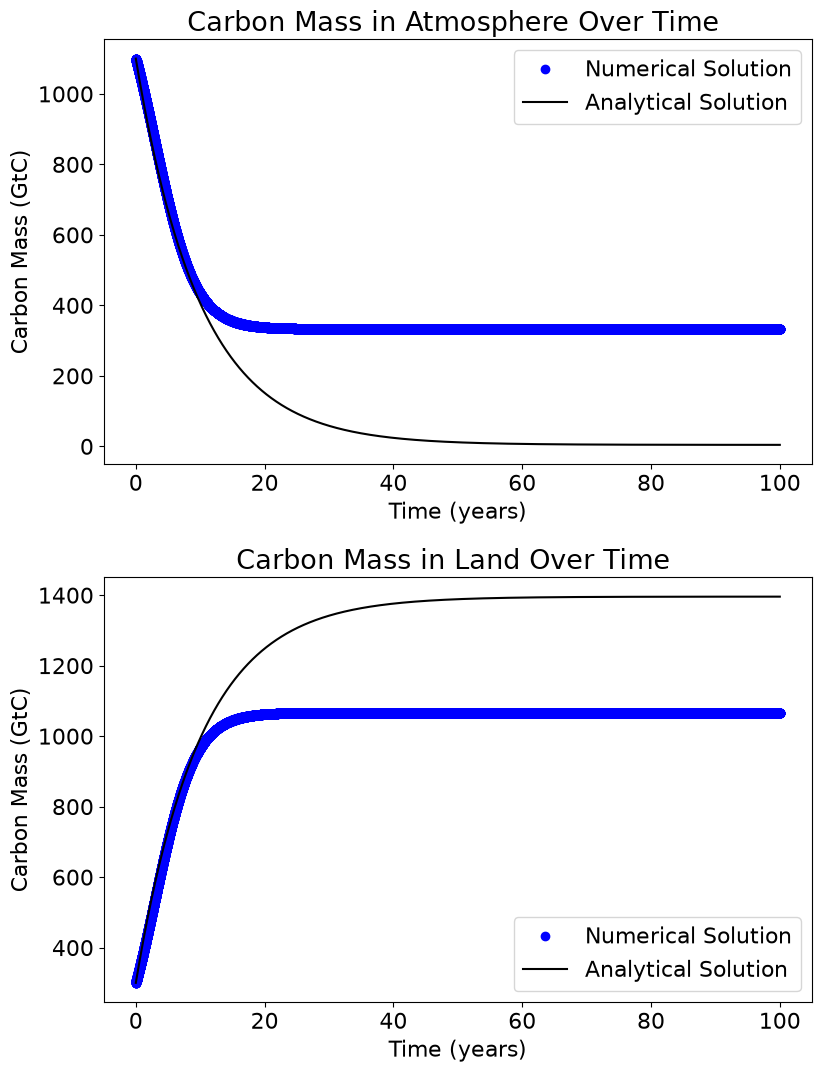

In [68]:
plt.figure(figsize=(8.5,11))
plt.rcParams.update({'font.size': 16})

plt.subplot(2,1,1)
plt.title('Carbon Mass in Atmosphere Over Time ')
plt.plot(t,M1,'bo', label='Numerical Solution')
plt.plot(t,M1_anlt,'k-', label='Analytical Solution')
plt.xlabel('Time (years)')
plt.ylabel('Carbon Mass (GtC)')
plt.legend()


plt.subplot(2,1,2)
plt.title('Carbon Mass in Land Over Time ')
plt.plot(t,M2,'bo', label='Numerical Solution')
plt.plot(t,M2_anlt,'k-', label='Analytical Solution')
plt.xlabel('Time (years)')
plt.ylabel('Carbon Mass (GtC)')
plt.legend()

plt.tight_layout() #added so plots don't overlap
plt.show()

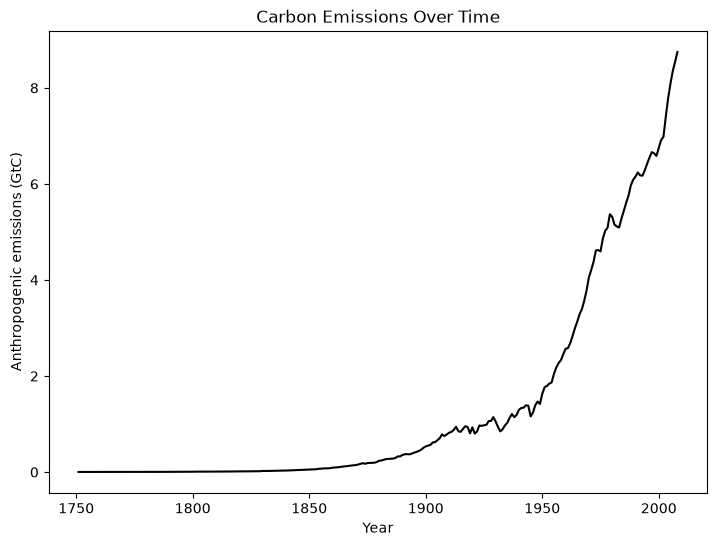

In [18]:
import pandas as pd
emissions = pd.read_csv('/Users/kyleformigli/Downloads/Modelling_Class_Psets/Mod2/AnthropogenicEmissions.1751_2008.csv')

plt.figure(figsize=(8.5, 6))# Make the figure


plt.plot(emissions['Year'], emissions['Anthropogenic emissions (GtC)'], 'k-')

plt.xlabel('Year')
plt.ylabel('Anthropogenic emissions (GtC)')
plt.title('Carbon Emissions Over Time')

plt.show()

In [26]:
# New time array for the emissions-driven model
ti_em = 1751.0
tf_em = 2008.0
dt_em = 1

M2i_em = 1066.66
M1i_em = 333.33

k12 = 0.0003 
k21 = 0.1




t_em = np.arange(ti_em, tf_em+dt_em, dt_em)
Nt_em = t_em.size
print('t_em has '+str(Nt_em)+' time steps')

#create empty arrays for new loop
M1_em = np.zeros(Nt_em)
M2_em = np.zeros(Nt_em)
dM1dt_arr = np.zeros(Nt_em) #stores change in each time step for the second figure 
dM2dt_arr = np.zeros(Nt_em)


emissions_df = pd.read_csv('/Users/kyleformigli/Downloads/Modelling_Class_Psets/Mod2/AnthropogenicEmissions.1751_2008.csv')
emissions = emissions_df['Anthropogenic emissions (GtC)'].values #define variable in emissions data
print('emissions has '+str(emissions.size)+' values')

for i in np.arange(Nt_em):
    if (i==0):
        M1_em[i] = M1i_em
        M2_em[i] = M2i_em
        # no rate of change exists yet at the very first time step
        
    else:
        dM1dt = k21*M2_em[i-1] - k12*M1_em[i-1]*M2_em[i-1] + emissions[i-1]
        dM2dt = k12*M1_em[i-1]*M2_em[i-1] - k21*M2_em[i-1]
        
        M1_em[i] = M1_em[i-1] + dM1dt*dt_em
        M2_em[i] = M2_em[i-1] + dM2dt*dt_em
        
        dM1dt_arr[i] = dM1dt  # save the rate of change for this step
        dM2dt_arr[i] = dM2dt

print(M1_em)
print(M2_em)

t_em has 258 time steps
emissions has 258 values
[333.33       333.33406666 333.336832   333.33871243 333.33999113
 333.34086065 333.34145191 333.34185397 333.34212736 333.34231326
 333.34243966 333.34252561 333.34258404 333.34262377 333.34265077
 333.34266913 333.3426816  333.34269008 333.34269583 333.34269973
 333.34270238 333.34370417 333.34438537 333.34484856 333.34516351
 333.34537766 333.34552327 333.34562226 333.34568956 333.34573531
 333.3457664  333.34678753 333.34748186 333.34795397 333.34827497
 333.34849322 333.3486416  333.34874247 333.34881104 333.34885764
 333.34888931 333.34991082 333.35060538 333.35107763 333.35139871
 333.351617   333.35176539 333.35286626 333.35361477 333.35412368
 333.35546967 333.35638483 333.35900703 333.35978993 333.36032219
 333.36068402 333.36192997 333.36277706 333.36335295 333.36374442
 333.3640105  333.36519133 333.3659941  333.36653982 333.36691076
 333.36816286 333.37001405 333.37227257 333.37380799 333.37485177
 333.37556127 333.37604348 

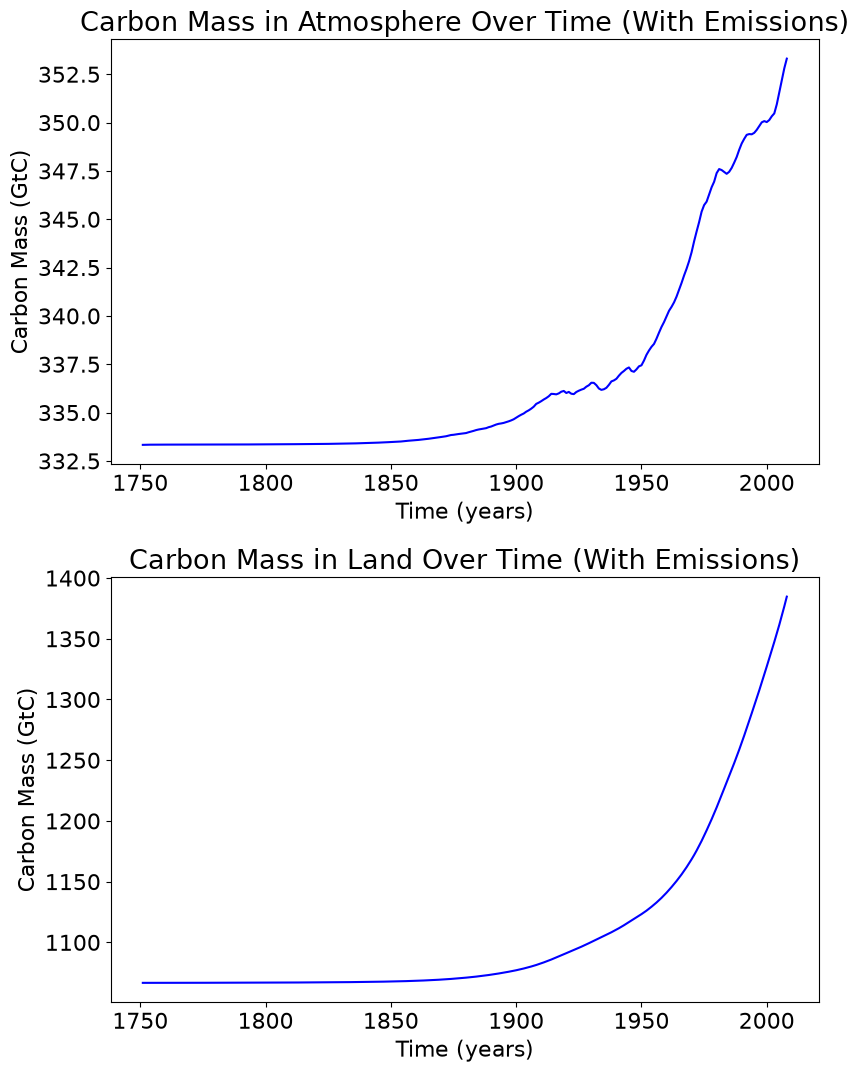

In [27]:
#Creating two pannel figure for mass in reservoirs with emissions
plt.figure(figsize=(8.5,11))
plt.rcParams.update({'font.size': 16})

plt.subplot(2,1,1)
plt.title('Carbon Mass in Atmosphere Over Time (With Emissions)')
plt.plot(t_em, M1_em, 'b-')
plt.xlabel('Time (years)')
plt.ylabel('Carbon Mass (GtC)')

plt.subplot(2,1,2)
plt.title('Carbon Mass in Land Over Time (With Emissions)')
plt.plot(t_em, M2_em, 'b-')
plt.xlabel('Time (years)')
plt.ylabel('Carbon Mass (GtC)')

plt.tight_layout()
plt.show()

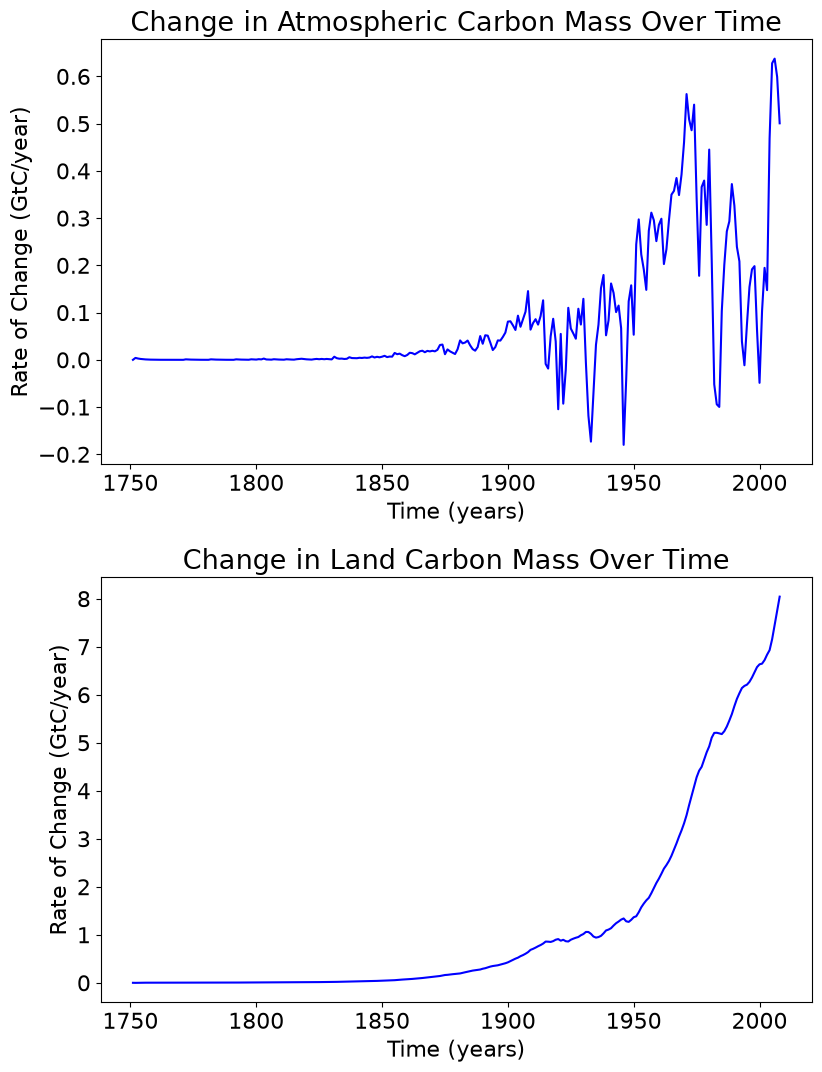

In [28]:
#create a two pannel figure for change in carbon in each reservoir over time 
plt.figure(figsize=(8.5,11))
plt.rcParams.update({'font.size': 16})

plt.subplot(2,1,1)
plt.title('Change in Atmospheric Carbon Mass Over Time')
plt.plot(t_em, dM1dt_arr, 'b-')
plt.xlabel('Time (years)')
plt.ylabel('Rate of Change (GtC/year)')

plt.subplot(2,1,2)
plt.title('Change in Land Carbon Mass Over Time')
plt.plot(t_em, dM2dt_arr, 'b-')
plt.xlabel('Time (years)')
plt.ylabel('Rate of Change (GtC/year)')

plt.tight_layout()
plt.show()

In [ ]:
#future prediction based on mitigation dataset 
#beta version, more efficient code is below 

future_prediction = pd.read_csv('/Users/kyleformigli/Downloads/Modelling_Class_Psets/Mod2/EmissionsMitigationScenarios.2008_2100.csv')
em_nz30 = future_prediction['NZ_2030'].values
em_nz50 = future_prediction['NZ_2050'].values
em_zg = future_prediction['ZEG'].values

t_em = np.arange(ti_em, tf_em+dt_em, dt_em)
Nt_em = t_em.size
print('t_em has '+str(Nt_em)+' time steps')

#create empty arrays for new loop

M1_em_nz30 = np.zeros(Nt_em) #for net zero 2030 scenario
M2_em_nz30 = np.zeros(Nt_em)    
M1_em_nz50 = np.zeros(Nt_em) #for net zero 2050 scenario
M2_em_nz50 = np.zeros(Nt_em)
M1_em_zg = np.zeros(Nt_em) #for zero growth scenario
M2_em_zg = np.zeros(Nt_em)
dM1dt_arr_nz30 = np.zeros(Nt_em) #for net zero 2030 scenario
dM2dt_arr_nz30 = np.zeros(Nt_em)
dM1dt_arr_nz50 = np.zeros(Nt_em) #for net zero 2050 scenario
dM2dt_arr_nz50 = np.zeros(Nt_em)
dM1dt_arr_zg = np.zeros(Nt_em) #for zero growth scenario
dM2dt_arr_zg = np.zeros(Nt_em)



for i in np.arange(Nt_em):
    if (i==0):
        M1_em_nz30[i] = M1i_em
        M2_em_nz30[i] = M2i_em
        M1_em_nz50[i] = M1i_em
        M2_em_nz50[i] = M2i_em
        M1_em_zg[i] = M1i_em
        M2_em_zg[i] = M2i_em
        # no rate of change exists yet at the very first time step
        
    else:
        dM1dt_em30 = k21*M2_em_nz30[i-1] - k12*M1_em_nz30[i-1]*M2_em_nz30[i-1] + em_nz30[i-1]
        dM2dt_em30 = k12*M1_em_nz30[i-1]*M2_em_nz30[i-1] - k21*M2_em_nz30[i-1]
        dM1dt_em50 = k21*M2_em_nz50[i-1] - k12*M1_em_nz50[i-1]*M2_em_nz50[i-1] + em_nz50[i-1]
        dM2dt_em50 = k12*M1_em_nz50[i-1]*M2_em_nz50[i-1] - k21*M2_em_nz50[i-1]
        dM1dt_em_zg = k21*M2_em_zg[i-1] - k12*M1_em_zg[i-1]*M2_em_zg[i-1] + em_zg[i-1]
        dM2dt_em_zg = k12*M1_em_zg[i-1]*M2_em_zg[i-1] - k21*M2_em_zg[i-1]
        
       
        M1_em_nz30[i] = M1_em_nz30[i-1] + dM1dt_em30*dt_em 
        M2_em_nz30[i] = M2_em_nz30[i-1] + dM2dt_em30*dt_em
        M1_em_nz50[i] = M1_em_nz50[i-1] + dM1dt_em50*dt_em
        M2_em_nz50[i] = M2_em_nz50[i-1] + dM2dt_em50*dt_em
        M1_em_zg[i] = M1_em_zg[i-1] + dM1dt_em_zg*dt_em
        M2_em_zg[i] = M2_em_zg[i-1] + dM2dt_em_zg*dt_em
        
       
        dM1dt_arr_nz30[i] = dM1dt_em30  # save the rate of change for this net zero 2030 scenario
        dM2dt_arr_nz30[i] = dM2dt_em30
        dM1dt_arr_nz50[i] = dM1dt_em50  # save the rate of change for this net zero 2050 scenario
        dM2dt_arr_nz50[i] = dM2dt_em50
        dM1dt_arr_zg[i] = dM1dt_em_zg  # save the rate of change for this zero growth scenario
        dM2dt_arr_zg[i] = dM2dt_em_zg



        



In [ ]:
#ai helped write code so I don't have to write the same code three times for each scenario.

future_prediction = pd.read_csv('/Users/kyleformigli/Downloads/Modelling_Class_Psets/Mod2/EmissionsMitigationScenarios.2008_2100.csv')
em_nz30 = future_prediction['NZ_2030'].values
em_nz50 = future_prediction['NZ_2050'].values
em_zg = future_prediction['ZEG'].values

ti_future = 2008.0
tf_future = 2100.0
dt_future = dt_em  # keep the same step size as the historical model

t_future = np.arange(ti_future, tf_future+dt_future, dt_future)
Nt_future = t_future.size
print('t_future has '+str(Nt_future)+' time steps')
print('em_nz30 has '+str(em_nz30.size)+' values')  # sanity check these line up


def run_carbon_model(emissions_array, M1i, M2i, k12, k21, dt, Nt):
    """Runs the carbon model loop for a given emissions scenario."""
    M1 = np.zeros(Nt)
    M2 = np.zeros(Nt)
    dM1dt_arr = np.full(Nt, np.nan)
    dM2dt_arr = np.full(Nt, np.nan)
    
    for i in np.arange(Nt):
        if i == 0:
            M1[i] = M1i
            M2[i] = M2i
        else:
            dM1dt = k21*M2[i-1] - k12*M1[i-1]*M2[i-1] + emissions_array[i-1]
            dM2dt = k12*M1[i-1]*M2[i-1] - k21*M2[i-1]
            
            M1[i] = M1[i-1] + dM1dt*dt
            M2[i] = M2[i-1] + dM2dt*dt
            
            dM1dt_arr[i] = dM1dt
            dM2dt_arr[i] = dM2dt
    
    return M1, M2, dM1dt_arr, dM2dt_arr


scenarios = {
    'Net Zero 2030': em_nz30,
    'Net Zero 2050': em_nz50,
    'Constant Emissions': em_zg
}

results = {}
for name, emissions_array in scenarios.items():
    results[name] = run_carbon_model(
        emissions_array,
        M1_em[-1],   # last value from the historical (1751-2008) model
        M2_em[-1],
        k12, k21, dt_future, Nt_future
    )

# Access any scenario's results like:
M1_nz30, M2_nz30, dM1dt_nz30, dM2dt_nz30 = results['Net Zero 2030']
M1_nz50, M2_nz50, dM1dt_nz50, dM2dt_nz50 = results['Net Zero 2050']
M1_zg,   M2_zg,   dM1dt_zg,   dM2dt_zg   = results['Constant Emissions']

t_future has 93 time steps
em_nz30 has 93 values


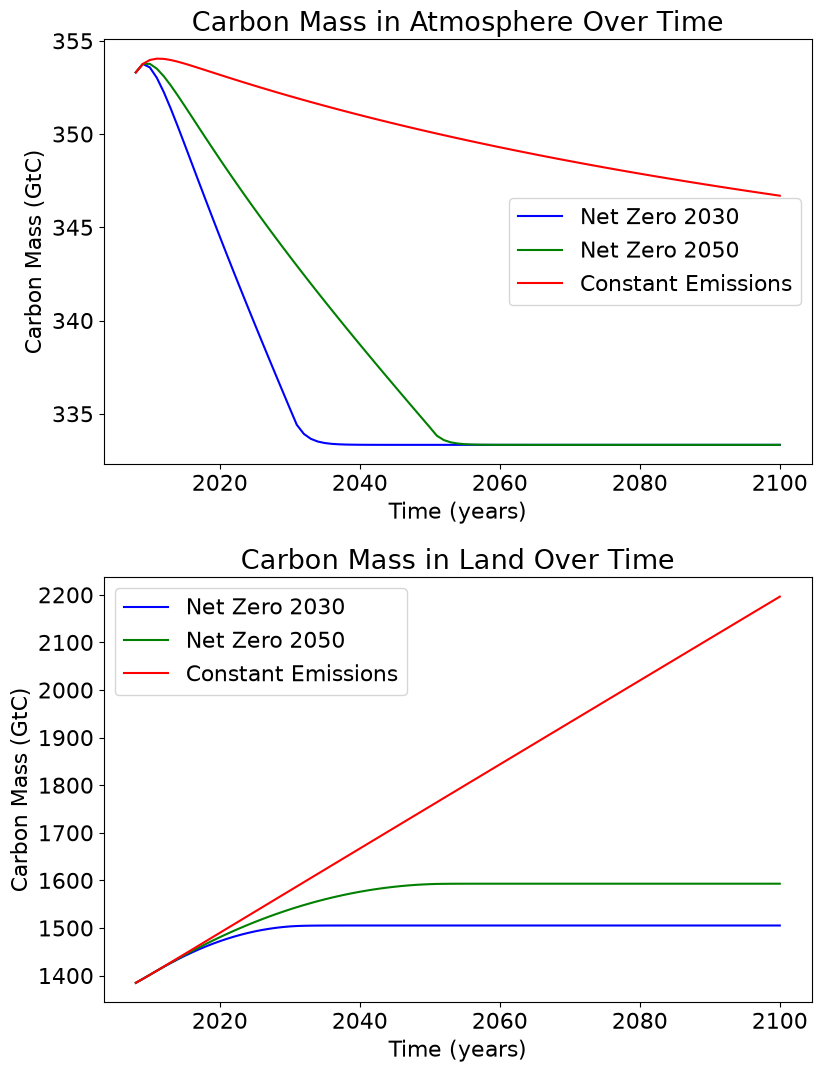

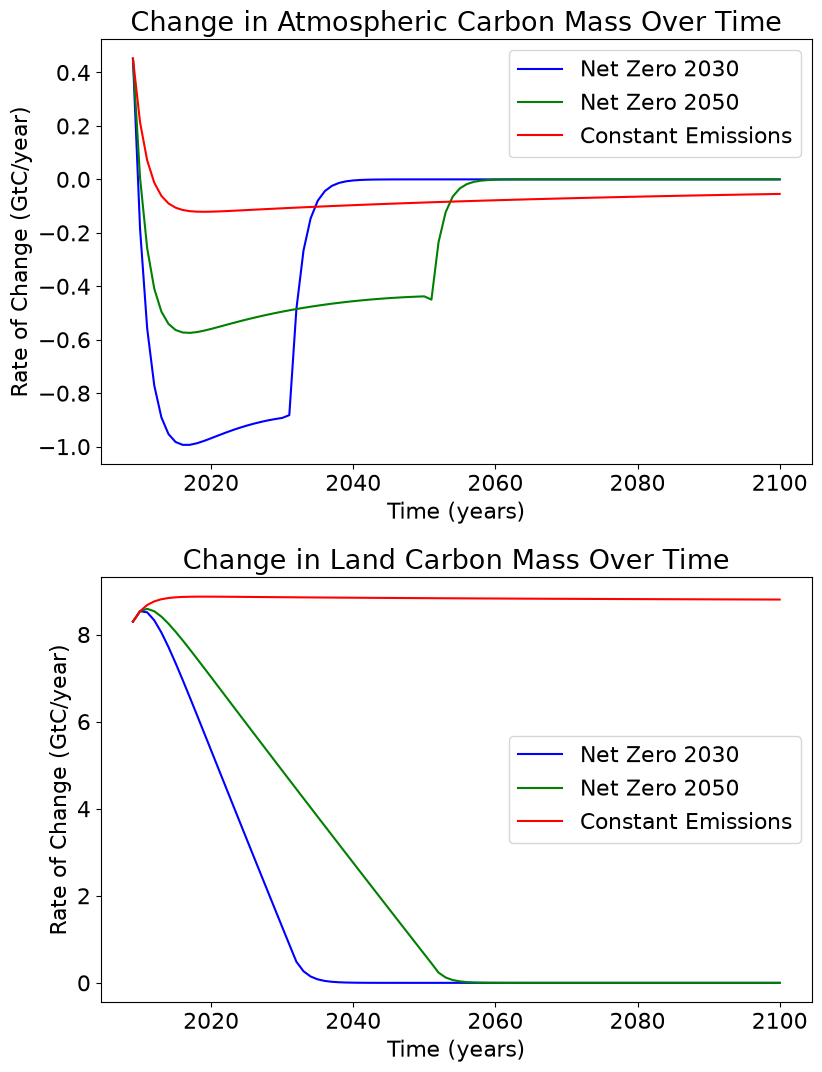

In [30]:
colors = {'Net Zero 2030': 'b', 'Net Zero 2050': 'g', 'Constant Emissions': 'r'}

# Figure 1: Mass over time in each reservoir
plt.figure(figsize=(8.5,11))
plt.rcParams.update({'font.size': 16})

plt.subplot(2,1,1)
plt.title('Carbon Mass in Atmosphere Over Time')
for name, (M1, M2, dM1dt_arr, dM2dt_arr) in results.items():
    plt.plot(t_future, M1, color=colors[name], label=name)
plt.xlabel('Time (years)')
plt.ylabel('Carbon Mass (GtC)')
plt.legend()

plt.subplot(2,1,2)
plt.title('Carbon Mass in Land Over Time')
for name, (M1, M2, dM1dt_arr, dM2dt_arr) in results.items():
    plt.plot(t_future, M2, color=colors[name], label=name)
plt.xlabel('Time (years)')
plt.ylabel('Carbon Mass (GtC)')
plt.legend()

plt.tight_layout()
plt.show()


# Figure 2: Rate of change over time in each reservoir
plt.figure(figsize=(8.5,11))
plt.rcParams.update({'font.size': 16})

plt.subplot(2,1,1)
plt.title('Change in Atmospheric Carbon Mass Over Time')
for name, (M1, M2, dM1dt_arr, dM2dt_arr) in results.items():
    plt.plot(t_future, dM1dt_arr, color=colors[name], label=name)
plt.xlabel('Time (years)')
plt.ylabel('Rate of Change (GtC/year)')
plt.legend()

plt.subplot(2,1,2)
plt.title('Change in Land Carbon Mass Over Time')
for name, (M1, M2, dM1dt_arr, dM2dt_arr) in results.items():
    plt.plot(t_future, dM2dt_arr, color=colors[name], label=name)
plt.xlabel('Time (years)')
plt.ylabel('Rate of Change (GtC/year)')
plt.legend()

plt.tight_layout()
plt.show()